In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
from scipy import linalg as la
from matplotlib import pyplot as plt
import matplotlib

from blochK.hamiltonian_engineering import (
    constraints_from_weyl_node,
    total_matrix_from_constraints,
    solve_constraint_matrix,
    vector_to_t_values,
    d_vector,
)

from blochK.hamiltonian_engineering.plotting import plot_3d_d_matrix


matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Palatino"],
    }
)

Hamiltonians are parametrised by a $t$-dictionary, which is provided as a set of:

$(\textup{hopping direction}) : (t_0, t_x, t_y, t_z)$

This indicates a hopping of the form $t_\mu \sigma_\mu$, or

$\begin{pmatrix}
t_0 + t_z & t_x -i t_y \\
t_x + i t_y& t_0 - t_z  
\end{pmatrix}$

Of course, $t$ values can be imaginary.

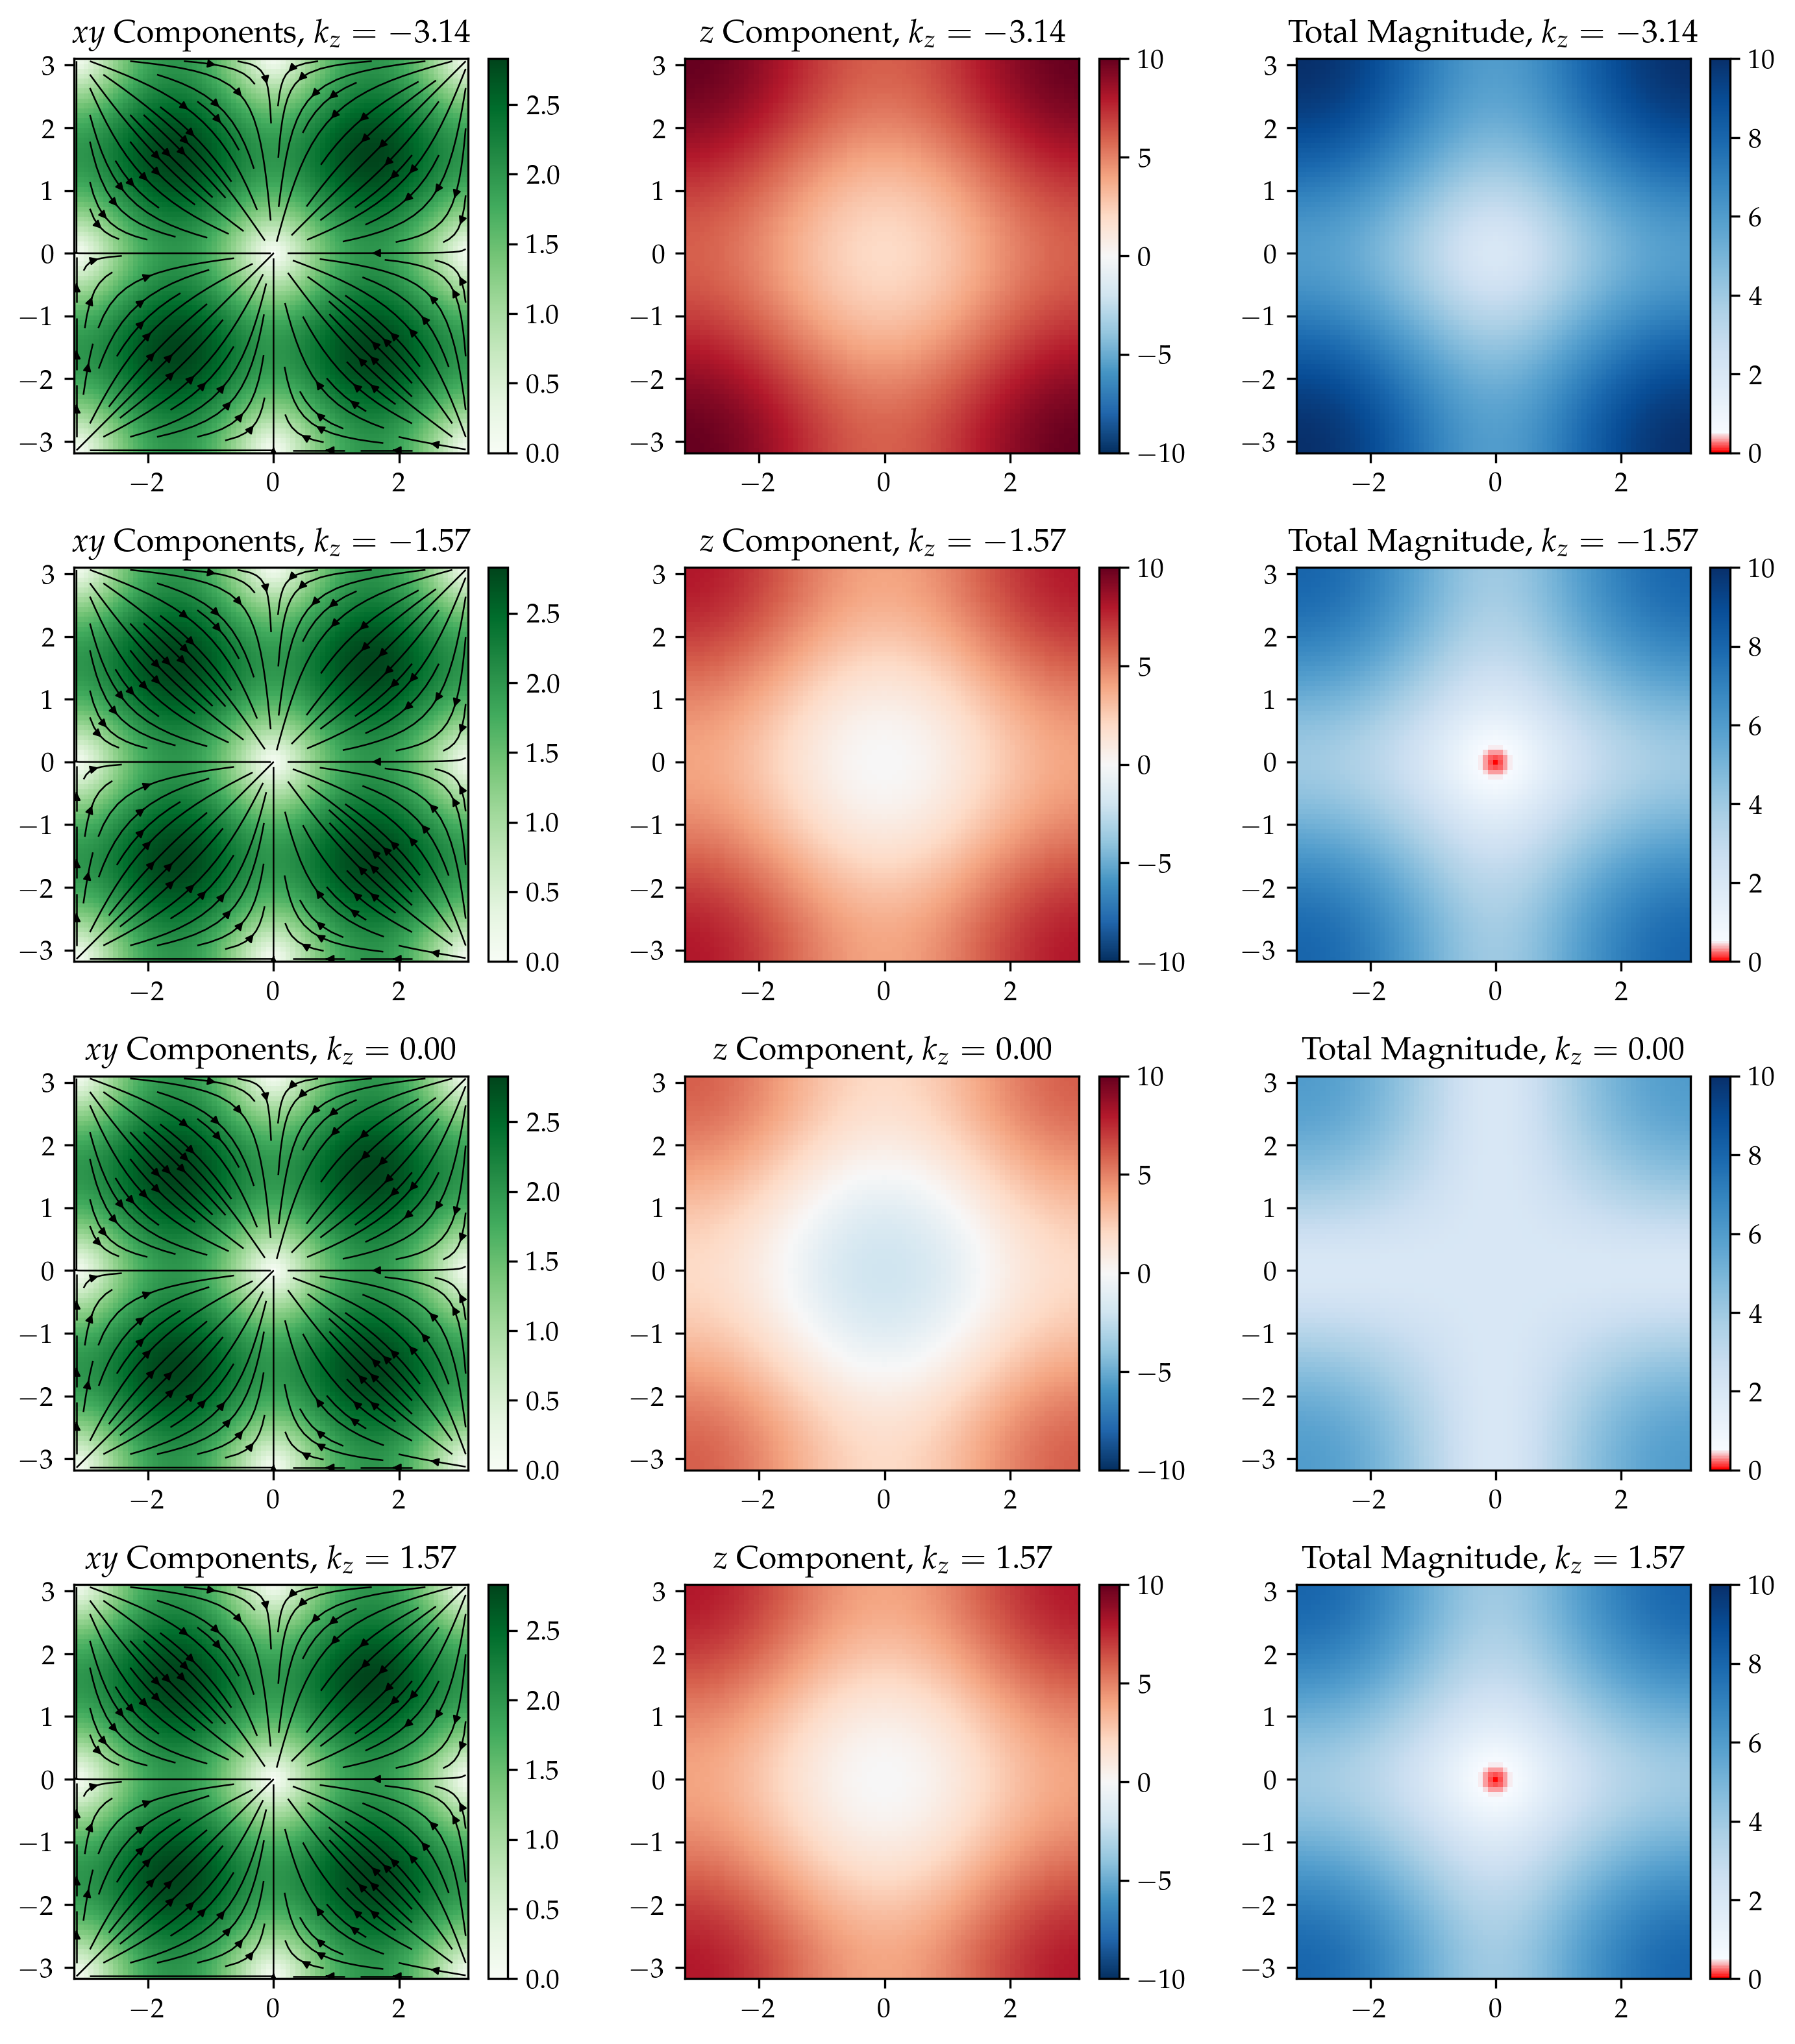

In [28]:
nx = 80
ny = 80
nz = 4
kx = np.linspace(-np.pi, np.pi, nx, endpoint=False)
ky = np.linspace(-np.pi, np.pi, ny, endpoint=False)
kz = np.linspace(-np.pi, np.pi, nz, endpoint=False)


# A weyl fermion toy model
u = 2
t_values = {
    (0, 0, 0): (0, 0, 0, u),
    (1, 0, 0): (0, 1j, 0, -1),
    (0, 1, 0): (0, 0, 1j, -1),
    (0, 0, 1): (0, 0, 0, -1),
}

plot_3d_d_matrix(kx, ky, kz, lambda k: d_vector(t_values, k))
plt.tight_layout()
plt.show()

To generate a Hamiltonian we have two requirements. First we specify which hoppings we want to include, which has to be a list of tuples. It helps to sort the list to stop any confusion.

Next we add a series of constraints. These always take the same form 

$(\textup{position}) (\textup{derivative}) (\textup{value})$

A constraint of the form

$(\Gamma) (\beta_x, \beta_y, \beta_z) (d_0, d_x, d_y, d_z)$

demands that 

$\left . \partial_{k_x}^{\beta_x}\partial_{k_y}^{\beta_y}\partial_{k_z}^{\beta_z} H \right |_{k = \Gamma} = \textbf d \cdot \sigma$

All of these constraints are then put together into a set.

In [29]:
allowed_hoppings = sorted(
    [
        (0, 0, 0),
        (1, 0, 0),
        (1, 1, 0),
        (0, 1, 0),
        (1, -1, 0),
        (0, 0, 1),
        (0, 0, 2),
    ]
)


c1 = constraints_from_weyl_node((np.pi, 0, np.pi * 0.5), (1, 1, 1))
c2 = constraints_from_weyl_node((np.pi, 0.0, -np.pi * 0.5), (1, 1, 1))

c3 = constraints_from_weyl_node((0, np.pi, np.pi * 0.5), (-1, 1, 1))
c4 = constraints_from_weyl_node((0, np.pi, -np.pi * 0.5), (-1, 1, 1))

print(f"The constraints for c1 weyl node are")
print(*c1, sep="\n")
print(f"")

constraints = c1 | c2 | c3 | c4

The constraints for c1 weyl node are
((3.141592653589793, 0, 1.5707963267948966), (1, 0, 0), (0, 1, 0, 0))
((3.141592653589793, 0, 1.5707963267948966), (0, 0, 0), (0, 0, 0, 0))
((3.141592653589793, 0, 1.5707963267948966), (0, 0, 1), (0, 0, 0, 1))
((3.141592653589793, 0, 1.5707963267948966), (0, 1, 0), (0, 0, 1, 0))



Next, we put all these constraints together in the form of a linear set of simultaneous equations which must be solved. These are then passed to the `solve_constraint_matrix` function, which returns a single solution as `sol` and the set of basis vectors that span the full solution space as `nullspace`. Thus, any Hamiltonian that satisfies the constraints can be constructed from these ingredients. Finally, we turn this vector back into a `t_values` like object.

In [ ]:
m, v = total_matrix_from_constraints(constraints, allowed_hoppings)
sol, null_basis = solve_constraint_matrix(m, v)

coeffs = np.random.randn(null_basis.shape[1])
random_solution = sol + null_basis @ coeffs

t = vector_to_t_values(random_solution, allowed_hoppings)

print("t values are:")
for a in t.keys():
    print(a, t[a].real.round(3), t[a].imag.round(3))

t values are:
(0, 0, 0) [ 0.495 -0.582  0.433  0.048] [0. 0. 0. 0.]
(0, 0, 1) [-0.  0. -0.  0.] [-0.  0.  0. -0.]
(0, 0, 2) [ 0.243 -0.477  0.431  0.347] [-0.  -0.   0.   0.5]
(0, 1, 0) [ 0.772 -0.647 -0.059 -0.   ] [ 0. -0. -0. -0.]
(1, -1, 0) [ 1.394 -0.639  0.499 -0.259] [ 0.  -0.  -0.5 -0. ]
(1, 0, 0) [ 0.772 -0.647 -0.059 -0.   ] [ 0.  1. -0.  0.]
(1, 1, 0) [-1.141  0.535 -0.497 -0.04 ] [-0.   0.   0.5 -0. ]


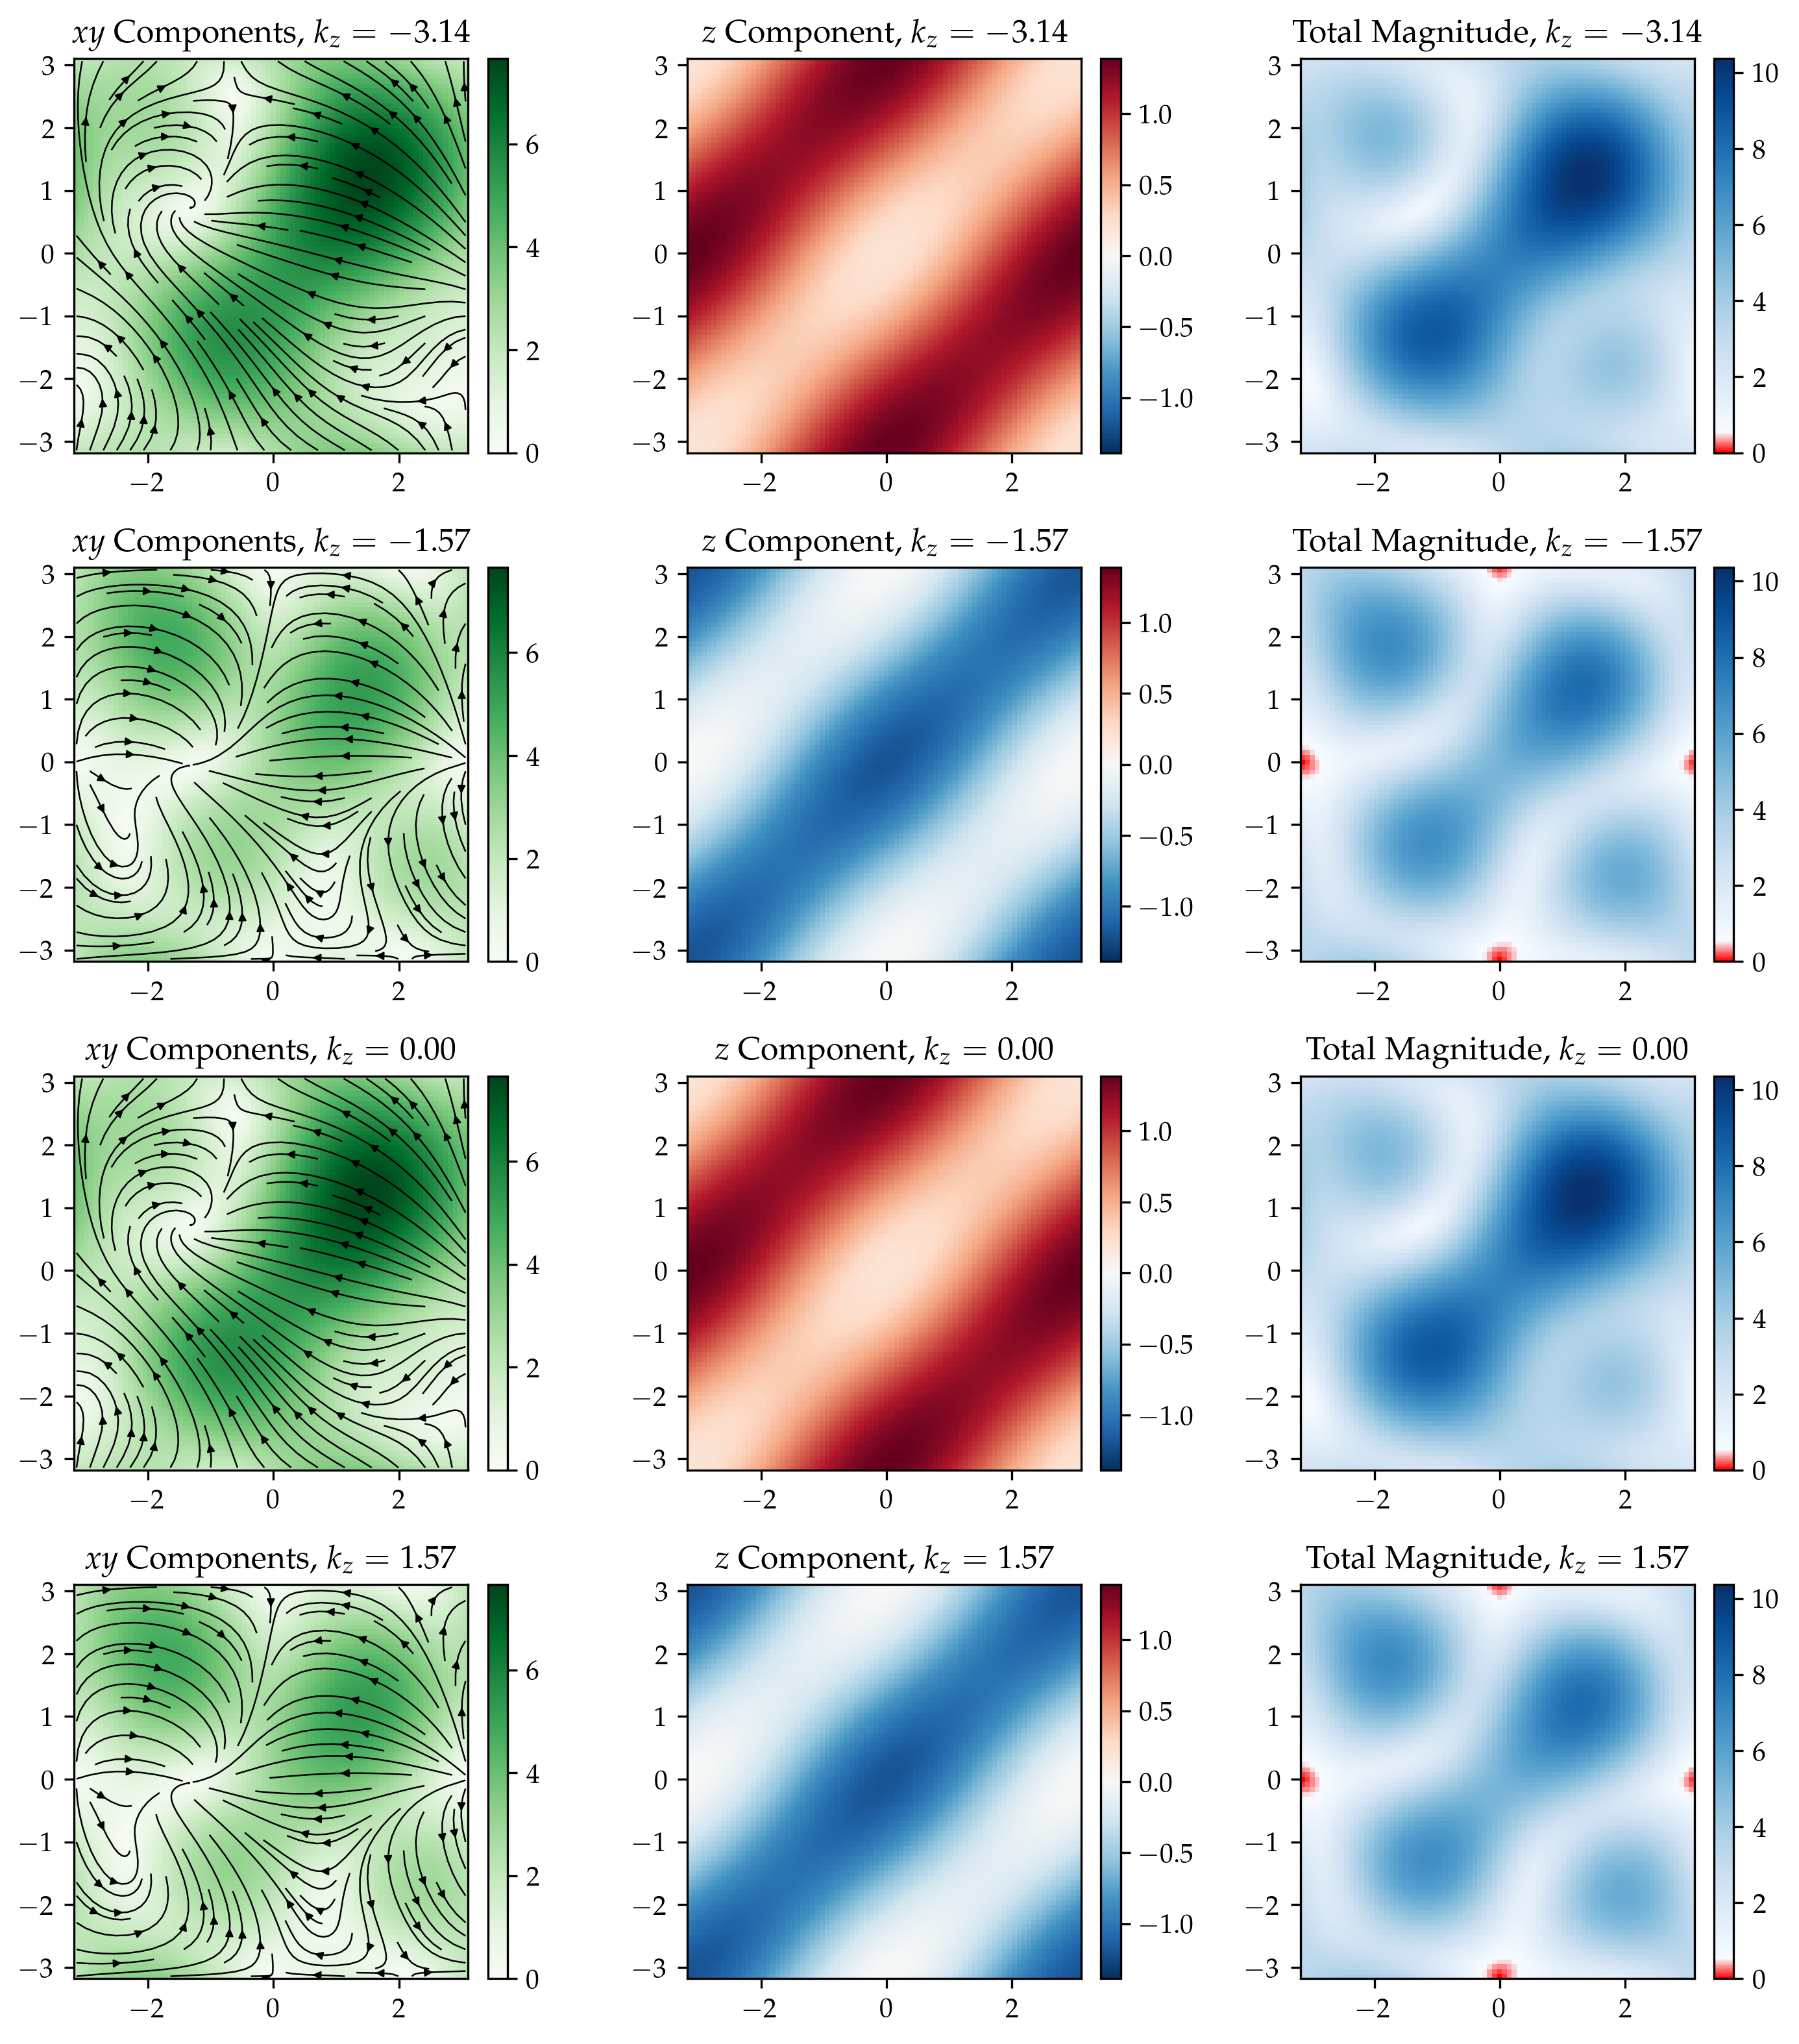

In [ ]:
nx = 80
ny = 80

kx = np.linspace(-np.pi, np.pi, nx, endpoint=False)
ky = np.linspace(-np.pi, np.pi, ny, endpoint=False)
kz = np.linspace(-np.pi, np.pi, 4, endpoint=False)

plot_3d_d_matrix(kx, ky, kz, lambda k: d_vector(t, k))
plt.tight_layout()
plt.show()